In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import statsmodels.formula.api as smf
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# Load dataset
# https://www.kaggle.com/datasets/nafees2006/mmm-dataset
# for now, use all the data for training
df = pd.read_csv("mmm_dataset.csv")

# Parse date column
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.dtypes)
df.head()

Dataset Shape: 209 rows, 12 columns
date                datetime64[us]
holiday                      int64
sales_promotion                str
competitor_spend           float64
instagram_spend            float64
google_ads_spend           float64
tv_spend                   float64
youtube_spend              float64
newspaper_spend            float64
influencer_spend           float64
ott_spend                  float64
sales                      float64
dtype: object


,date,holiday,sales_promotion,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend,sales
0,2022-01-03,0,BOGO,262550.0,54880.0,NaN,47580.0,57190.0,NaN,34610.0,NaN,1084031.0
1,2022-01-10,0,Normal,310750.0,67170.0,NaN,60140.0,64150.0,NaN,18000.0,NaN,1225796.0
2,2022-01-17,0,Flash Sale,361600.0,90520.0,NaN,52180.0,30710.0,NaN,48300.0,NaN,1445628.0
3,2022-01-24,0,Normal,293650.0,77800.0,NaN,41940.0,39610.0,NaN,49160.0,NaN,1445965.0
4,2022-01-31,0,Normal,343700.0,87050.0,NaN,29720.0,23430.0,NaN,34790.0,NaN,1370267.0


In [7]:
# Check missing value summary
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Clean dataset: Drop rows with missing target ('sales') and impute missing channel spend with 0
df_clean = df.dropna(subset=['sales']).copy()

spend_cols = [
    'instagram_spend', 'google_ads_spend', 'tv_spend', 
    'youtube_spend', 'newspaper_spend', 'influencer_spend', 
    'ott_spend', 'competitor_spend'
]

# Filling missing ad spend with 0
df_clean[spend_cols] = df_clean[spend_cols].fillna(0)

print("\nShape after cleaning:", df_clean.shape)
df_clean.describe().T[['mean', 'std', 'min', '50%', 'max']]

--- Missing Values Count ---
date                 0
holiday              0
sales_promotion      0
competitor_spend     9
instagram_spend     50
google_ads_spend    80
tv_spend            57
youtube_spend       65
newspaper_spend     64
influencer_spend    59
ott_spend           50
sales                3
dtype: int64

Shape after cleaning: (206, 12)


,mean,std,min,50%,max
date,2024-01-02 20:02:19.805825,NaN,2022-01-03 00:00:00,2024-01-04 12:00:00,2025-12-29 00:00:00
holiday,0.058252,0.234791,0.0,0.0,1.0
competitor_spend,284442.718447,69508.300051,0.0,293675.0,384850.0
instagram_spend,54658.203883,33829.594378,0.0,64005.0,104660.0
google_ads_spend,57541.699029,47650.309881,0.0,74480.0,126320.0
tv_spend,37513.300971,25087.231594,0.0,45910.0,73170.0
youtube_spend,28661.31068,22376.126754,0.0,30750.0,66780.0
newspaper_spend,5111.553398,3577.925208,0.0,6375.0,10180.0
influencer_spend,22569.466019,16829.439195,0.0,23510.0,53180.0
ott_spend,43951.456311,27361.290652,0.0,50720.0,82390.0


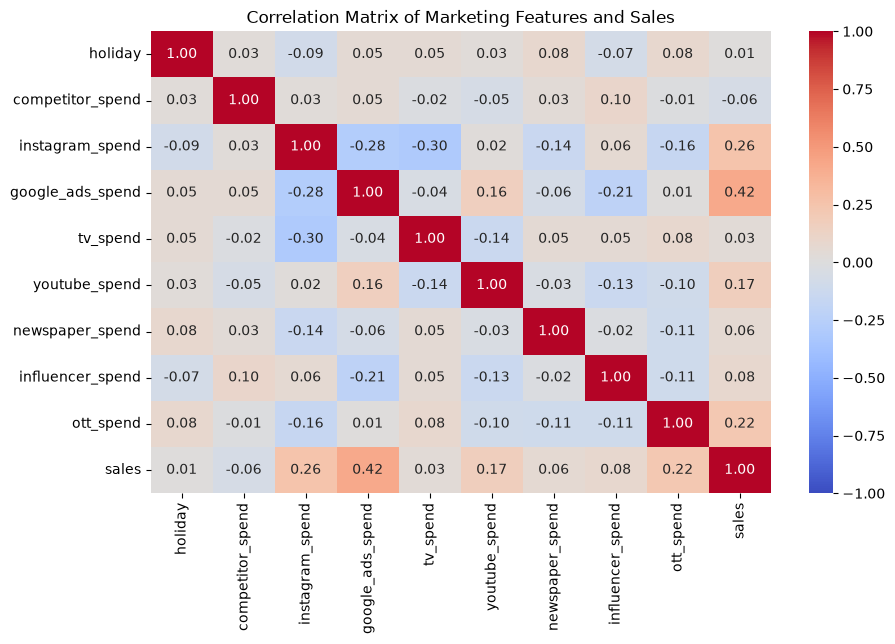

In [10]:
# Visualize pairwise correlations with Target variable
plt.figure(figsize=(10, 6))
numeric_df = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Marketing Features and Sales")
plt.show()

In [12]:
# Baseline model predicting Sales using OTT Spend
# also do using from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
X_simple = sm.add_constant(df_clean['ott_spend'])
y = df_clean['sales']

model_simple = sm.OLS(y, X_simple).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     10.37
Date:                Tue, 15 Sep 2026   Prob (F-statistic):            0.00149
Time:                        13:54:41   Log-Likelihood:                -2962.5
No. Observations:                 206   AIC:                             5929.
Df Residuals:                     204   BIC:                             5936.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.165e+06   5.65e+04     38.299      0.0

In [13]:
# Select channel predictors
features = [
    'instagram_spend', 'google_ads_spend', 'tv_spend', 
    'youtube_spend', 'newspaper_spend', 'influencer_spend', 
    'ott_spend', 'competitor_spend', 'holiday'
]

X_multi = sm.add_constant(df_clean[features])

# Fit OLS Model
model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     26.81
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           7.77e-30
Time:                        13:56:20   Log-Likelihood:                -2885.0
No. Observations:                 206   AIC:                             5790.
Df Residuals:                     196   BIC:                             5823.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              1.08e+06   1.34e+05  

In [18]:
# 2. Basic Pivot Table: Average Sales & Spend per Promotion Type
pivot_basic = pd.pivot_table(
    df_clean,
    index="sales_promotion",
    values=["sales", "tv_spend", "google_ads_spend", "instagram_spend"],
    aggfunc="mean",
)

print("--- Average Sales & Channel Spend by Promotion Type ---")
print(pivot_basic)

--- Average Sales & Channel Spend by Promotion Type ---
                 google_ads_spend  instagram_spend         sales      tv_spend
sales_promotion                                                               
BOGO                 57456.666667     56119.375000  2.377369e+06  35622.291667
Coupons              58936.250000     55762.343750  2.392405e+06  41510.000000
Flash Sale           58194.666667     50233.333333  2.273175e+06  38047.333333
Normal               56339.620253     53716.075949  2.235150e+06  35323.037975


In [14]:
# Convert categorical promotion column to dummy variables
df_encoded = pd.get_dummies(df_clean, columns=['sales_promotion'], drop_first=True, dtype=int)

# Identify updated features including new promo dummy columns
promo_cols = [c for c in df_encoded.columns if c.startswith('sales_promotion_')]
all_features = features + promo_cols

X_full = sm.add_constant(df_encoded[all_features])
y_full = df_encoded['sales']

model_full = sm.OLS(y_full, X_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     20.40
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.21e-28
Time:                        13:56:55   Log-Likelihood:                -2883.3
No. Observations:                 206   AIC:                             5793.
Df Residuals:                     193   BIC:                             5836.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

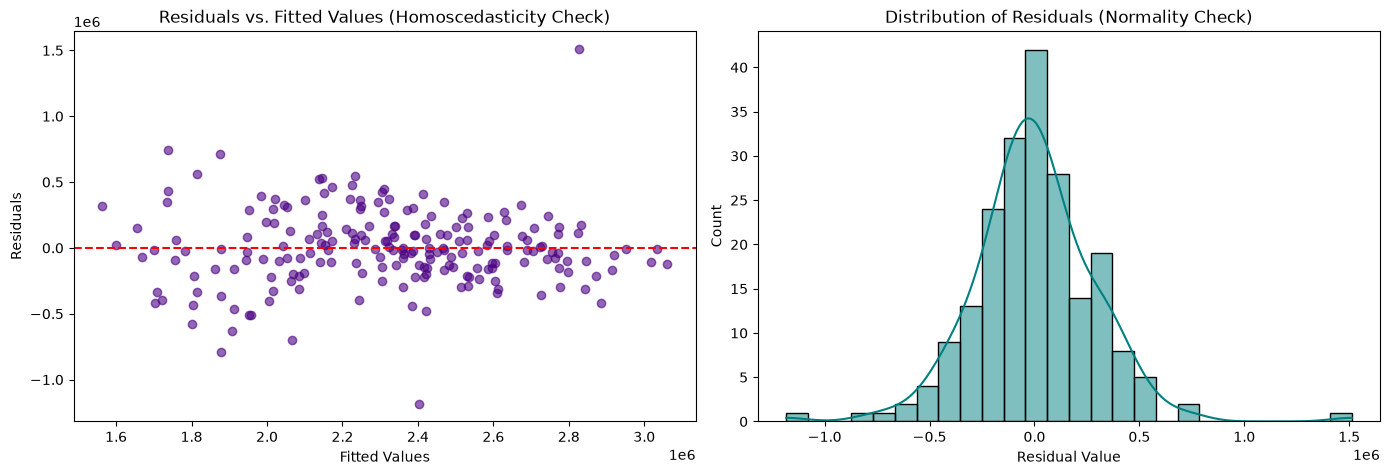

In [15]:
# 2. Residual Diagnostics Plots
residuals = model_full.resid
fitted_vals = model_full.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_vals, residuals, alpha=0.6, color='indigo')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted Values (Homoscedasticity Check)')

# Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Residuals (Normality Check)')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()

In [19]:
# 2. Residual Diagnostics Plots
residuals = model_full.resid
fitted_vals = model_full.fittedvalues

# 1. Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(residuals**2))

# 2. Mean Absolute Error (MAE)
mae = np.mean(np.abs(residuals))

print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")

RMSE: $289,965.50
MAE:  $210,217.64


In [29]:
# Define custom input scenario (e.g., planned budget for next week)
new_scenario = {
    "const": 1.0,  # Required for model intercept
    "competitor_spend": 300000.0,
    "instagram_spend": 75000.0,
    "google_ads_spend": 90000.0,
    "tv_spend": 50000.0,
    "youtube_spend": 40000.0,
    "newspaper_spend": 7000.0,
    "influencer_spend": 30000.0,
    "ott_spend": 60000.0,
    "holiday": 0,
    "sales_promotion_Coupons": 1,  # Promotion set to 'Coupons'
    "sales_promotion_Flash Sale": 0,
    "sales_promotion_Normal": 0,
}

# Convert dictionary to single-row Pandas DataFrame
input_df = pd.DataFrame([new_scenario])

# Point Forecast
predicted_sales = model_full.predict(input_df)[0]

print(f"Forecasted Weekly Sales: ${predicted_sales:,.2f}")

Forecasted Weekly Sales: $5,309,857.94


In [21]:
# sklearn with textbook custom
!pip install mlba


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.6/18.6 MB 35.9 MB/s  0:00:00 eta 0:00:01


In [27]:
import mlba
from sklearn.linear_model import BayesianRidge, Lasso, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import cross_validate, train_test_split

model = LinearRegression()
model.fit(X_full, y_full)

# print coefficients
print(pd.DataFrame({'Predictor': X_full.columns, 'coefficient': model.coef_}))

# print performance measures (training data)
mlba.regressionSummary(y_true=y_full, y_pred=model.predict(X_full))



                     Predictor    coefficient
0                        const       0.000000
1              instagram_spend       7.132691
2             google_ads_spend       5.703567
3                     tv_spend       3.317146
4                youtube_spend       2.848749
5              newspaper_spend      25.456887
6             influencer_spend       6.177053
7                    ott_spend       5.599799
8             competitor_spend      -0.789745
9                      holiday   -6792.150750
10     sales_promotion_Coupons  -39495.655309
11  sales_promotion_Flash Sale -120203.397689
12      sales_promotion_Normal  -84746.507094

Regression statistics

Mean Error (ME) : -0.0000
Root Mean Squared Error (RMSE) : 289965.4964
Mean Absolute Error (MAE) : 210217.6379
Mean Percentage Error (MPE) : -1.9892
Mean Absolute Percentage Error (MAPE) : 10.0687


In [28]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector, SequentialFeatureSelector
efs = ExhaustiveFeatureSelector(model,
            min_features=1, max_features=len(predictors),
            cv=5, scoring='neg_root_mean_squared_error',
            print_progress=False, n_jobs=4)
efs = efs.fit(train_X, train_y)
assert efs.best_score_ is not None

print(f'Best score: {- efs.best_score_:.2f}')
print(f'Best subset (indices): {efs.best_idx_}')
print(f'Best subset (corresponding names):\n{efs.best_feature_names_}')

ModuleNotFoundError: No module named 'mlxtend'